In [1]:
!pip install simpy

In [2]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [4]:
def customer(env, name, server, service_rate, wait_times):
    arrival_time = env.now

    with server.request() as request:
        yield request

        wait_time = env.now - arrival_time
        wait_times.append(wait_time)

        service_time = random.expovariate(service_rate)
        yield env.timeout(service_time)


def customer_generator(env, server, arrival_rate, service_rate, wait_times, simulation_time):
    customer_id = 0

    while env.now < simulation_time:
        interarrival_time = random.expovariate(arrival_rate)
        yield env.timeout(interarrival_time)

        customer_id += 1
        env.process(customer(env, customer_id, server, service_rate, wait_times))


def run_simulation(arrival_rate, service_rate, num_servers, simulation_time):
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=num_servers)

    wait_times = []

    env.process(customer_generator(
        env, server, arrival_rate, service_rate, wait_times, simulation_time
    ))

    env.run(until=simulation_time)

    avg_wait_time = np.mean(wait_times) if len(wait_times) > 0 else 0
    max_wait_time = np.max(wait_times) if len(wait_times) > 0 else 0
    customers_served = len(wait_times)
    utilization = arrival_rate / (service_rate * num_servers)

    return avg_wait_time, max_wait_time, customers_served, utilization

In [5]:
random.seed(42)
np.random.seed(42)

simulation_results = []

for i in range(1000):
    arrival_rate = np.random.uniform(0.5, 5.0)
    service_rate = np.random.uniform(1.0, 6.0)
    num_servers = np.random.randint(1, 6)
    simulation_time = np.random.randint(100, 500)

    avg_wait_time, max_wait_time, customers_served, utilization = run_simulation(
        arrival_rate,
        service_rate,
        num_servers,
        simulation_time
    )

    simulation_results.append({
        "arrival_rate": arrival_rate,
        "service_rate": service_rate,
        "num_servers": num_servers,
        "simulation_time": simulation_time,
        "utilization": utilization,
        "customers_served": customers_served,
        "max_wait_time": max_wait_time,
        "avg_wait_time": avg_wait_time
    })

df = pd.DataFrame(simulation_results)
df.head()

,arrival_rate,service_rate,num_servers,simulation_time,utilization,customers_served,max_wait_time,avg_wait_time
0,2.185431,5.753572,3,171,0.126613,377,0.049074,0.000130
1,3.193963,1.780093,3,314,0.598089,1002,2.247863,0.166732
2,0.761376,5.330881,4,459,0.035706,343,0.000000,0.000000
3,3.686327,1.102922,2,443,1.671163,1002,174.255242,89.463442
4,4.245992,2.061696,4,376,0.514866,1609,1.137937,0.051462


In [6]:
df.to_csv("simulation_dataset.csv", index=False)
df.describe()

,arrival_rate,service_rate,num_servers,simulation_time,utilization,customers_served,max_wait_time,avg_wait_time
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.684068,3.486789,2.989000,300.930000,0.453329,772.705000,10.899015,5.035458
std,1.317517,1.480537,1.431408,115.185558,0.521445,511.706824,37.852599,19.101957
min,0.504633,1.000942,1.000000,100.000000,0.019376,53.000000,0.000000,0.000000
25%,1.528891,2.194337,2.000000,201.000000,0.146897,355.500000,0.098362,0.000280
50%,2.719788,3.422929,3.000000,299.000000,0.278681,651.500000,0.525992,0.009061
75%,3.800842,4.792282,4.000000,401.000000,0.546651,1106.750000,2.101385,0.171666
max,4.998730,5.997720,5.000000,499.000000,4.508797,2400.000000,342.990386,183.141326


In [7]:
X = df[[
    "arrival_rate",
    "service_rate",
    "num_servers",
    "simulation_time",
    "utilization",
    "customers_served",
    "max_wait_time"
]]

y = df["avg_wait_time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42, n_estimators=100),
    "KNN Regressor": KNeighborsRegressor(),
    "SVR": SVR()
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2 Score", ascending=False)
results_df

,Model,MAE,RMSE,R2 Score
1,Ridge Regression,0.534190,1.173195,0.995785
0,Linear Regression,0.527271,1.177938,0.995750
5,Extra Trees,0.357213,1.305874,0.994777
3,Random Forest,0.348377,1.366717,0.994279
6,KNN Regressor,0.605127,2.023940,0.987454
2,Decision Tree,0.546442,2.144833,0.985911
4,Gradient Boosting,0.506738,2.231317,0.984751
7,SVR,2.951859,13.714411,0.423951


In [9]:
results_df.to_csv("model_comparison_results.csv", index=False)

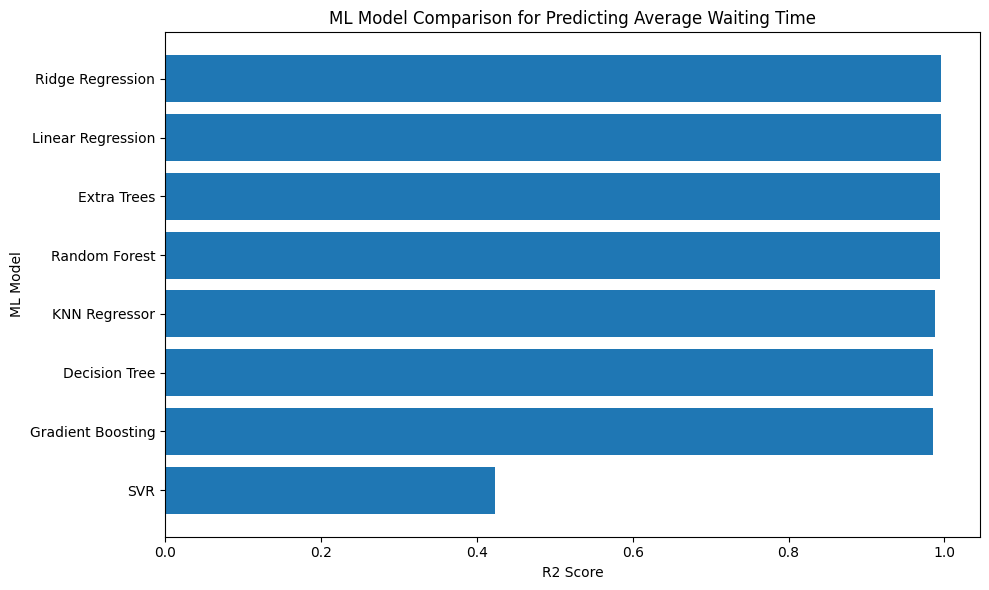

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["R2 Score"])
plt.xlabel("R2 Score")
plt.ylabel("ML Model")
plt.title("ML Model Comparison for Predicting Average Waiting Time")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("model_comparison_graph.png")
plt.show()

In [11]:
best_model = results_df.iloc[0]

print("Best ML Model:", best_model["Model"])
print("MAE:", best_model["MAE"])
print("RMSE:", best_model["RMSE"])
print("R2 Score:", best_model["R2 Score"])

Best ML Model: Ridge Regression
MAE: 0.5341903280104231
RMSE: 1.1731947408120622
R2 Score: 0.9957845371358253
